# Colocalisation workflow


### Import libraries
documentation for the various modules:
* [`numpy`](https://numpy.org/) - scientific computing
* [`scikit_image`](https://scikit-image.org/docs/stable/api/skimage.html) (a.k.a. [`skimage`](https://scikit-image.org/docs/stable/api/skimage.html)) - image processing and computer vision
* [`matplotlib`](https://matplotlib.org/) - visualisations
* [`pandas`](https://pandas.pydata.org/docs/user_guide/index.html) - data managing

In [3]:
import numpy as np

from skimage import io
from skimage import filters
from skimage import measure

import matplotlib.pyplot as plt

import pandas as pd

### Open images

cells have been stained for *nuclei (DAPI, ch0)*, *gp91-phox (AlexaFluor488, ch1)* and *p47-phox (AlexaFluor586, ch2)* and imaged with fluorescent microscopy. 


In [478]:
# read .tif file
im_read = io.imread('../../Data/Nox2/pIC_120min_15.tif')

In [479]:
# print image type
print('Image type:', type(im_read))

Image type: <class 'numpy.ndarray'>


In [480]:
# print image dimensions
print('Image dimensions:', im_read.shape)

Image dimensions: (1024, 1024, 3)


The image dimensions are currently in the (y, x, c) format. Ideally, by convention, we would want the dimensions of the image to be (c, x, y). We can rearrange the dimensions by using the numpy function `transpose`.

In [481]:
# rearrange
im_all = np.transpose(im_read, (2, 0, 1))
print('New image dimensions:', im_all.shape)

New image dimensions: (3, 1024, 1024)


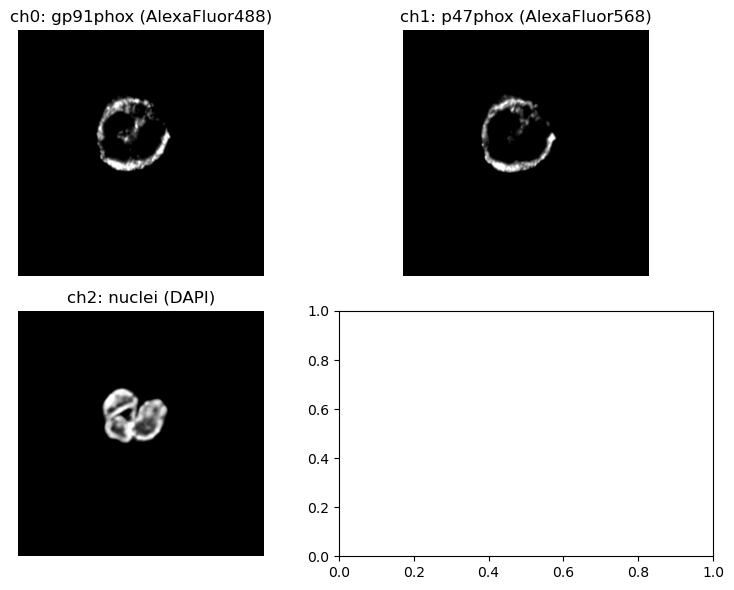

In [482]:
# display all channels 
fig, axs = plt.subplots(2, 2, figsize=(8,6))

axs[0, 0].imshow(im_all[0,], cmap='gray')
axs[0, 0].set_title('ch0: gp91phox (AlexaFluor488)')
axs[0, 0].axis('off')

axs[0, 1].imshow(im_all[1,], cmap='gray')
axs[0, 1].set_title('ch1: p47phox (AlexaFluor568)')
axs[0, 1].axis('off')

axs[1, 0].imshow(im_all[2,], cmap='gray')
axs[1, 0].set_title('ch2: nuclei (DAPI)')
axs[1, 0].axis('off')

plt.tight_layout()

In [483]:
# select the gp91phox channel
im = im_all[0,]

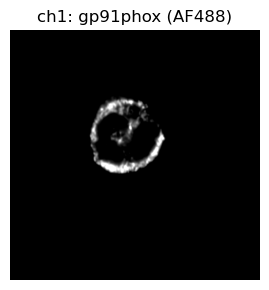

In [484]:
# display image
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(im, cmap='gray')
ax.set_title('ch1: gp91phox (AF488)')
ax.axis('off')
plt.tight_layout()

### Use filters to suppress noise

Many image processing tasks include filtering to suppress noise, improve signal-to-noise ratio, or bring out the features of the image we are interested in.

Please keep in mind that often by applying filters we change the histogram of the image, and, therefore, we won't be able to perform some quantifications related to signal intensity **after** filtering.

In this example, we are not interested in quantifying signal intensities (i.e., how bright the nuclei are), so we're good to proceed!

[`skimage`](https://scikit-image.org/docs/stable/api/skimage.html) has many filters already built in! You can find them in the submodule [`skimage.filters`](https://scikit-image.org/docs/stable/api/skimage.filters.html).

Here we'll test a [Gaussian blur](https://en.wikipedia.org/wiki/Gaussian_blur), which is a standard method to reduce image noise by blurring details. One important parameter is `sigma`, which is the standard deviation of the Gaussian kernel. You can think of it as the "size of the brush" you'll use to smooth the image features.

In [485]:
# Gaussian blur (sigma=5)
im_gauss = filters.gaussian(im, sigma=2)

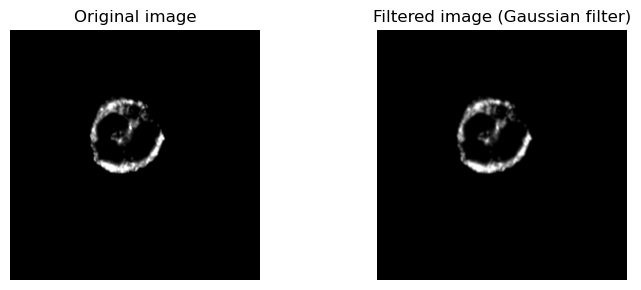

In [486]:
# display original image next to filtered one
fig, axs = plt.subplots(1, 2, figsize=(8,3))

axs[0].imshow(im, cmap='gray')
axs[0].set_title('Original image')
axs[0].axis('off')

axs[1].imshow(im_gauss, cmap='gray')
axs[1].set_title('Filtered image (Gaussian filter)')
axs[1].axis('off')

plt.tight_layout()

### Segment images using grey level thresholding

The next step in our pipeline is segmentation. This is the process by which we separate the foreground (`True`) from the background (`False`) so that the subsequent analyses are performed only on the regions of interest.

One simple way to segment images is by gray level thresholding: we "keep" all the pixels with values above a threshold (foreground) and we "discard" the rest (background).

There are different ways to set this threshold by exploiting different algorigthms. With the function [`skimage.filters.try_all_threshold`](https://scikit-image.org/docs/stable/api/skimage.filters.html#skimage.filters.try_all_threshold), we can visualise a few options and decide which one performs best for our data! [Otsu's thresholding](https://en.wikipedia.org/wiki/Otsu%27s_method) is a common choice for this type of images, so after checking its performance on the example image, we'll apply it.

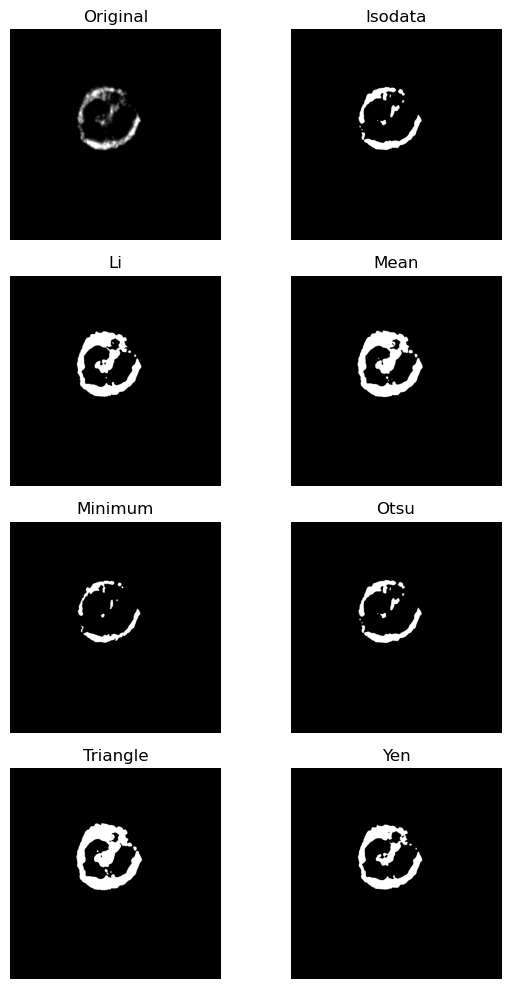

In [487]:
# display various options for gray level thresholding
fig, ax = filters.try_all_threshold(im_gauss, figsize=(8,10), verbose=False)
plt.tight_layout()

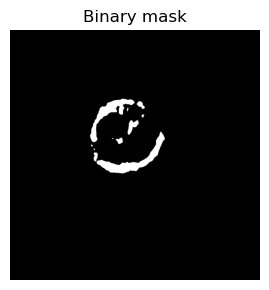

In [488]:
# Triangle thresholding performs quite well in this example, so we'll proceed by applying it to our image and display 
thresh = filters.threshold_isodata(im_gauss)
im_thresh = im_gauss >= thresh

# display the binary mask
fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(im_thresh, cmap='gray')
ax.set_title('Binary mask')
ax.axis('off')
plt.tight_layout()

In [489]:
pearsonsR1 = measure.pearson_corr_coeff(im_all[0,], im_all[1,], mask=im_thresh)

print("Pearsons R gp91phox-p47 is", pearsonsR1)



Pearsons R gp91phox-p47 is PearsonRResult(statistic=0.5008739221838134, pvalue=0.0)
